In [ ]:
pip install anndata scanpy pooch scipy matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import anndata as ad
import anndata
import matplotlib.pyplot as plt
import scanpy as sc
import pooch
from scipy.sparse import csr_matrix

print("anndata version:", ad.__version__)

anndata version: 0.12.14


/tmp/ipykernel_31334/2060735975.py:10: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata version:", ad.__version__)


In [ ]:
counts = csr_matrix(np.random.poisson(1, size=(100, 2000)), dtype=np.float32)
adata = ad.AnnData(counts)
print("Initial AnnData:\n", adata)
print("adata.X (sparse matrix):\n", adata.X)

Initial AnnData:
 AnnData object with n_obs × n_vars = 100 × 2000
adata.X (sparse matrix):
 <Compressed Sparse Row sparse matrix of dtype 'float32'
	with 126497 stored elements and shape (100, 2000)>
  Coords	Values
  (0, 0)	2.0
  (0, 1)	1.0
  (0, 5)	1.0
  (0, 7)	3.0
  (0, 8)	2.0
  (0, 10)	2.0
  (0, 16)	1.0
  (0, 17)	1.0
  (0, 18)	1.0
  (0, 19)	2.0
  (0, 20)	2.0
  (0, 21)	2.0
  (0, 24)	1.0
  (0, 25)	1.0
  (0, 26)	1.0
  (0, 27)	2.0
  (0, 29)	1.0
  (0, 30)	1.0
  (0, 31)	1.0
  (0, 32)	1.0
  (0, 34)	1.0
  (0, 36)	1.0
  (0, 37)	1.0
  (0, 38)	1.0
  (0, 39)	1.0
  :	:
  (99, 1959)	1.0
  (99, 1963)	1.0
  (99, 1965)	2.0
  (99, 1966)	1.0
  (99, 1967)	1.0
  (99, 1968)	4.0
  (99, 1971)	1.0
  (99, 1972)	3.0
  (99, 1973)	1.0
  (99, 1975)	1.0
  (99, 1976)	1.0
  (99, 1977)	1.0
  (99, 1978)	1.0
  (99, 1979)	1.0
  (99, 1980)	2.0
  (99, 1983)	2.0
  (99, 1984)	1.0
  (99, 1985)	1.0
  (99, 1988)	1.0
  (99, 1989)	1.0
  (99, 1993)	1.0
  (99, 1996)	1.0
  (99, 1997)	3.0
  (99, 1998)	1.0
  (99, 1999)	3.0


In [ ]:
adata.obs_names = [f"Cell_{i:d}" for i in range(adata.n_obs)]
adata.var_names = [f"Gene_{i:d}" for i in range(adata.n_vars)]
print("First 10 obs_names:", adata.obs_names[:10].tolist())

First 10 obs_names: ['Cell_0', 'Cell_1', 'Cell_2', 'Cell_3', 'Cell_4', 'Cell_5', 'Cell_6', 'Cell_7', 'Cell_8', 'Cell_9']


In [ ]:
subset_view = adata[["Cell_1", "Cell_10"], ["Gene_5", "Gene_1900"]]
print("Subset view:", subset_view)

Subset view: View of AnnData object with n_obs × n_vars = 2 × 2


In [ ]:
ct = np.random.choice(["B", "T", "Monocyte"], size=(adata.n_obs,))
adata.obs["cell_type"] = pd.Categorical(ct)
print("adata.obs (first 5 rows):\n", adata.obs.head())
print("Updated AnnData:", adata)

adata.obs (first 5 rows):
        cell_type
Cell_0         B
Cell_1         B
Cell_2         T
Cell_3         T
Cell_4         B
Updated AnnData: AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'cell_type'


In [ ]:
bdata = adata[adata.obs.cell_type == "B"]
print("B-cell subset:", bdata)

B-cell subset: View of AnnData object with n_obs × n_vars = 30 × 2000
    obs: 'cell_type'


In [ ]:
adata.obsm["X_umap"] = np.random.normal(0, 1, size=(adata.n_obs, 2))
adata.varm["gene_stuff"] = np.random.normal(0, 1, size=(adata.n_vars, 5))
print("obsm keys:", list(adata.obsm.keys()))
print("AnnData after obsm/varm:", adata)

obsm keys: ['X_umap']
AnnData after obsm/varm: AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'cell_type'
    obsm: 'X_umap'
    varm: 'gene_stuff'


In [ ]:
adata.uns["random"] = [1, 2, 3]
print("adata.uns:", dict(adata.uns))

adata.uns: {'random': [1, 2, 3]}


In [ ]:
adata.layers["log_transformed"] = np.log1p(adata.X)
print("AnnData with layers:", adata)

AnnData with layers: AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'cell_type'
    uns: 'random'
    obsm: 'X_umap'
    varm: 'gene_stuff'
    layers: 'log_transformed'


In [ ]:
df_log = adata.to_df(layer="log_transformed")
print("log_transformed DataFrame (first 3 rows, first 5 cols):\n", df_log.iloc[:3, :5])

log_transformed DataFrame (first 3 rows, first 5 cols):
           Gene_0    Gene_1    Gene_2    Gene_3    Gene_4
Cell_0  1.098612  0.693147  0.000000  0.000000  0.000000
Cell_1  0.693147  0.693147  1.098612  0.000000  0.693147
Cell_2  1.098612  0.000000  0.693147  0.693147  0.000000


In [ ]:
adata.write("my_results.h5ad", compression="gzip")
print("Saved to my_results.h5ad")

Saved to my_results.h5ad


In [ ]:
obs_meta = pd.DataFrame(
    {
        "time_yr":         np.random.choice([0, 2, 4, 8], adata.n_obs),
        "subject_id":      np.random.choice(["subject 1", "subject 2", "subject 4", "subject 8"], adata.n_obs),
        "instrument_type": np.random.choice(["type a", "type b"], adata.n_obs),
        "site":            np.random.choice(["site x", "site y"], adata.n_obs),
    },
    index=adata.obs.index,
)
adata = ad.AnnData(adata.X, obs=obs_meta, var=adata.var)
print("AnnData with rich obs metadata:", adata)

# View
view_5x2 = adata[:5, ["Gene_1", "Gene_3"]]
print("View (5×2):", view_5x2)

# Explicit copy
adata_subset = adata[:5, ["Gene_1", "Gene_3"]].copy()
print("Copy from view:", adata_subset)

# Modify through a view
print("Before:", adata[:3, "Gene_1"].X.toarray().tolist())
adata[:3, "Gene_1"].X = [0, 0, 0]
print("After zeroing:", adata[:3, "Gene_1"].X.toarray().tolist())

# Implicit copy via attribute assignment (triggers ImplicitModificationWarning)
adata_sub3 = adata[:3, ["Gene_1", "Gene_2"]]
adata_sub3.obs["foo"] = range(3)
print("After implicit copy:", adata_sub3)

# Boolean indexing
print("Cells from time_yr 2 or 4 (first 5):\n", adata[adata.obs.time_yr.isin([2, 4])].obs.head())

AnnData with rich obs metadata: AnnData object with n_obs × n_vars = 100 × 2000
    obs: 'time_yr', 'subject_id', 'instrument_type', 'site'
View (5×2): View of AnnData object with n_obs × n_vars = 5 × 2
    obs: 'time_yr', 'subject_id', 'instrument_type', 'site'
Copy from view: AnnData object with n_obs × n_vars = 5 × 2
    obs: 'time_yr', 'subject_id', 'instrument_type', 'site'
Before: [[1.0], [1.0], [0.0]]
After zeroing: [[0.0], [0.0], [0.0]]
After implicit copy: AnnData object with n_obs × n_vars = 3 × 2
    obs: 'time_yr', 'subject_id', 'instrument_type', 'site', 'foo'
Cells from time_yr 2 or 4 (first 5):
          time_yr subject_id instrument_type    site
Cell_0         4  subject 1          type a  site x
Cell_1         4  subject 4          type a  site x
Cell_9         4  subject 2          type b  site x
Cell_10        4  subject 1          type b  site y
Cell_11        4  subject 1          type b  site x


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:639: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
  if self._handle_view_X_cow(value):
/tmp/ipykernel_31334/3198331881.py:23: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata[:3, "Gene_1"].X = [0, 0, 0]
/tmp/ipykernel_31334/3198331881.py:28: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub3.obs["foo"] = range(3)


In [ ]:
# OLD (deprecated/removed):
# adata_backed = ad.read("my_results.h5ad", backed="r")

# NEW — use read_h5ad directly:
adata_backed = ad.io.read_h5ad("my_results.h5ad", backed="r")
print("Is backed:", adata_backed.isbacked)
print("Backed filename:", adata_backed.filename)
adata_backed.file.close()

Is backed: True
Backed filename: my_results.h5ad


In [ ]:
# 1.12 Backed / partial reading
adata_backed = ad.io.read_h5ad("my_results.h5ad", backed="r")
print("Is backed:", adata_backed.isbacked)
print("Backed filename:", adata_backed.filename)
adata_backed.file.close()

Is backed: True
Backed filename: my_results.h5ad


In [ ]:
datapath = pooch.retrieve(
    path=pooch.os_cache("scverse_tutorials"),
    url=(
        "https://exampledata.scverse.org/tutorials/"
        "scverse-getting-started-anndata-pbmc3k_processed.h5ad"
    ),
    known_hash="md5:b80deb0997f96b45d06f19c694e46243",
)
adata = anndata.read_h5ad(datapath)
print("Loaded AnnData:\n", adata)

Loaded AnnData:
 AnnData object with n_obs × n_vars = 2638 × 11505
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types'
    var: 'gene_names', 'n_cells', 'gene_ids'
    uns: 'louvain', 'louvain_colors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'raw'
    obsp: 'distances_all'


In [ ]:
print("adata.X (sparse):\n", adata.X)
print("Non-zero values sample:", adata.X.data[:5])
print("Non-zero indices sample:", adata.X.indices[:5])
print("Sparsity (fraction non-zero):", round(adata.X.nnz / np.prod(adata.X.shape), 4))

adata.X (sparse):
 <Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2076576 stored elements and shape (2638, 11505)>
  Coords	Values
  (0, 19)	0.6496620774269104
  (0, 52)	0.6496620774269104
  (0, 58)	1.0402015447616577
  (0, 118)	0.6496620774269104
  (0, 131)	0.6496620774269104
  (0, 146)	0.6496620774269104
  (0, 147)	0.6496620774269104
  (0, 180)	3.6509344577789307
  (0, 181)	0.6496620774269104
  (0, 182)	0.6496620774269104
  (0, 208)	1.0402015447616577
  (0, 210)	1.7181968688964844
  (0, 263)	0.6496620774269104
  (0, 270)	0.6496620774269104
  (0, 291)	0.6496620774269104
  (0, 313)	0.6496620774269104
  (0, 324)	0.6496620774269104
  (0, 336)	0.6496620774269104
  (0, 357)	1.0402015447616577
  (0, 362)	0.6496620774269104
  (0, 380)	2.6894383430480957
  (0, 394)	0.6496620774269104
  (0, 402)	0.6496620774269104
  (0, 411)	0.6496620774269104
  (0, 418)	0.6496620774269104
  :	:
  (2637, 11103)	0.7506172060966492
  (2637, 11191)	0.7506172060966492
  (2637, 11210)	0.7506172060966

Layers: ['raw']
raw layer dtype: int64
raw layer sample values: [1 1 2 1 1]
Layers after CPM: ['raw', 'counts_per_million']


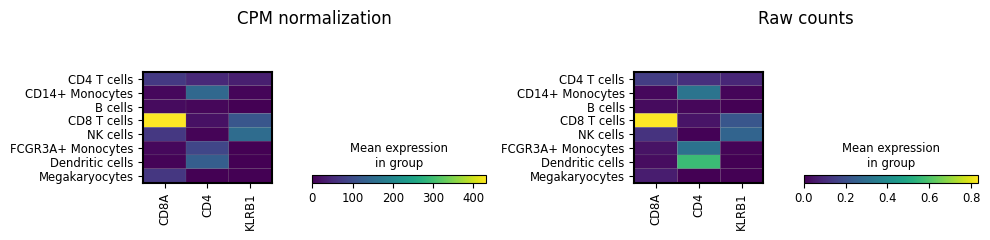

In [ ]:
print("Layers:", list(adata.layers.keys()))
print("raw layer dtype:", adata.layers["raw"].dtype)
print("raw layer sample values:", adata.layers["raw"].data[:5])

# Add counts-per-million layer
adata.layers["counts_per_million"] = adata.layers["raw"].copy()
sc.pp.normalize_total(adata, target_sum=10**6, layer="counts_per_million")
print("Layers after CPM:", list(adata.layers.keys()))

# Plot CPM vs raw
genes_of_interest = ["CD8A", "CD4", "KLRB1"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5))
sc.pl.matrixplot(adata, groupby="louvain_cell_types", var_names=genes_of_interest,
                 layer="counts_per_million", ax=ax1, show=False)
ax1.set_title("CPM normalization")
sc.pl.matrixplot(adata, groupby="louvain_cell_types", var_names=genes_of_interest,
                 layer="raw", ax=ax2, show=False)
ax2.set_title("Raw counts")
plt.tight_layout()
plt.show()

In [ ]:
print("obs columns:", adata.obs.keys().tolist())
print("obs head:\n", adata.obs.head())

# Count B cells
n_b = sum(adata.obs["louvain_cell_types"] == "B cells")
print(f"Number of B cells: {n_b}")

# Add quality flag
adata.obs["is_low_quality"] = adata.obs["percent_mito"] > 0.03
print("obs after quality flag:\n", adata.obs.head())
print("var head:\n", adata.var.head())

obs columns: ['n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types']
obs head:
                   n_genes  percent_mito  n_counts louvain_cell_types
cell_barcode                                                        
AAACATACAACCAC-1      781      0.030178    2419.0        CD4 T cells
AAACATTGAGCTAC-1     1352      0.037936    4903.0            B cells
AAACATTGATCAGC-1     1131      0.008897    3147.0        CD4 T cells
AAACCGTGCTTCCG-1      960      0.017431    2639.0    CD14+ Monocytes
AAACCGTGTATGCG-1      522      0.012245     980.0           NK cells
Number of B cells: 342
obs after quality flag:
                   n_genes  percent_mito  n_counts louvain_cell_types  \
cell_barcode                                                           
AAACATACAACCAC-1      781      0.030178    2419.0        CD4 T cells   
AAACATTGAGCTAC-1     1352      0.037936    4903.0            B cells   
AAACATTGATCAGC-1     1131      0.008897    3147.0        CD4 T cells   
AAACCGTGCTTCCG-1      9

In [ ]:
print("obs_names (first 5):", adata.obs_names[:5].tolist())
print("var_names (first 5):", adata.var_names[:5].tolist())

# Switch to Ensembl IDs
adata.var_names = adata.var["gene_ids"]
print("var after re-index to Ensembl:\n", adata.var.head(3))

# Restore gene names
adata.var_names = adata.var["gene_names"]
print("var restored:\n", adata.var.head(3))

obs_names (first 5): ['AAACATACAACCAC-1', 'AAACATTGAGCTAC-1', 'AAACATTGATCAGC-1', 'AAACCGTGCTTCCG-1', 'AAACCGTGTATGCG-1']
var_names (first 5): ['LINC00115', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4']
var after re-index to Ensembl:
                 gene_names  n_cells         gene_ids
gene_ids                                            
ENSG00000225880  LINC00115       18  ENSG00000225880
ENSG00000188976      NOC2L      258  ENSG00000188976
ENSG00000187961     KLHL17        9  ENSG00000187961
var restored:
            gene_names  n_cells         gene_ids
gene_names                                     
LINC00115   LINC00115       18  ENSG00000225880
NOC2L           NOC2L      258  ENSG00000188976
KLHL17         KLHL17        9  ENSG00000187961


In [ ]:
# By name
adata_small = adata[:5, ["LYZ", "FOS", "MALAT1"]]
print("adata_small shape:", adata_small.shape)
print("X (dense):\n", adata_small.X.toarray())
print("raw layer:\n", adata_small.layers["raw"].toarray())
print("obs:\n", adata_small.obs)
print("var:\n", adata_small.var)

# Boolean: keep high-quality cells only
adata_hq = adata[~adata.obs["is_low_quality"], :]
print("High-quality cells:", adata_hq.n_obs)
print("adata_hq obs (first 5):\n", adata_hq.obs.head())

adata_small shape: (5, 3)
X (dense):
 [[0.6496621  2.4036813  3.8249342 ]
 [0.8553989  0.64266497 4.174533  ]
 [0.878057   2.8014445  4.7918878 ]
 [3.0494576  1.6464083  2.3237872 ]
 [0.         0.         3.923651  ]]
raw layer:
 [[  1  11  49]
 [  3   2 142]
 [  2  22 170]
 [ 24   5  11]
 [  0   0  22]]
obs:
                   n_genes  percent_mito  n_counts louvain_cell_types  \
cell_barcode                                                           
AAACATACAACCAC-1      781      0.030178    2419.0        CD4 T cells   
AAACATTGAGCTAC-1     1352      0.037936    4903.0            B cells   
AAACATTGATCAGC-1     1131      0.008897    3147.0        CD4 T cells   
AAACCGTGCTTCCG-1      960      0.017431    2639.0    CD14+ Monocytes   
AAACCGTGTATGCG-1      522      0.012245     980.0           NK cells   

                  is_low_quality  
cell_barcode                      
AAACATACAACCAC-1            True  
AAACATTGAGCTAC-1            True  
AAACATTGATCAGC-1           False  
AAACCGT

obsm keys: ['X_pca', 'X_tsne', 'X_umap']
  X_pca: shape (2638, 50)
  X_tsne: shape (2638, 2)
  X_umap: shape (2638, 2)


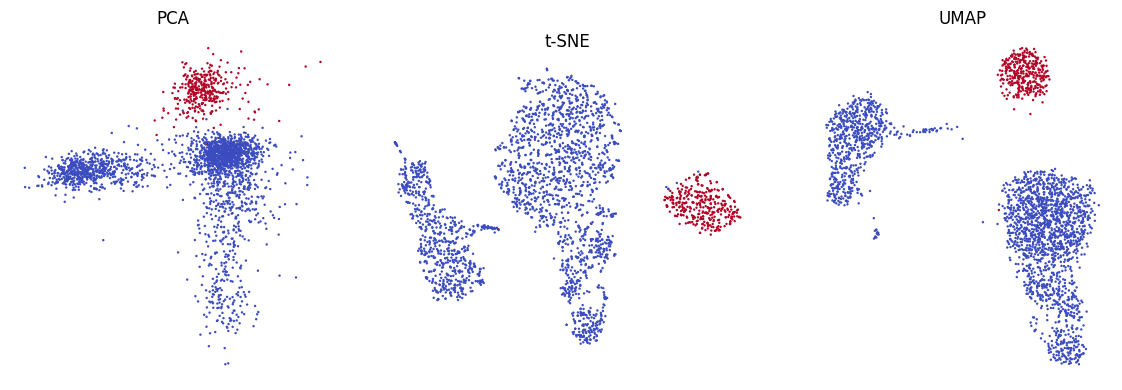

In [ ]:
print("obsm keys:", list(adata.obsm.keys()))
for key in adata.obsm:
    print(f"  {key}: shape {adata.obsm[key].shape}")

# Plot PCA / t-SNE / UMAP
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
b_flag = adata.obs["louvain_cell_types"] == "B cells"
scatter_kw = dict(s=3, linewidth=0, cmap="coolwarm")

for ax, key, title in zip(axes, ["X_pca", "X_tsne", "X_umap"], ["PCA", "t-SNE", "UMAP"]):
    ax.scatter(adata.obsm[key][:, 0], adata.obsm[key][:, 1],
               c=b_flag.astype(int), **scatter_kw)
    ax.set_title(title)
    ax.axis("off")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

obsp keys: ['distances_all']
distances_all shape: (2638, 2638)


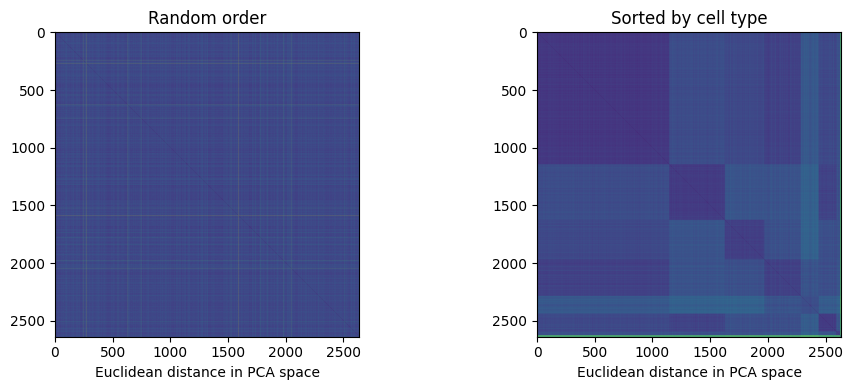

In [ ]:
print("obsp keys:", list(adata.obsp.keys()))
print("distances_all shape:", adata.obsp["distances_all"].shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(adata.obsp["distances_all"])
axes[0].set_title("Random order")
axes[0].set_xlabel("Euclidean distance in PCA space")

reorder = np.argsort(adata.obs["louvain_cell_types"])
axes[1].imshow(adata[reorder, :].obsp["distances_all"])
axes[1].set_title("Sorted by cell type")
axes[1].set_xlabel("Euclidean distance in PCA space")

plt.tight_layout()
plt.show()

In [ ]:
print("uns keys:", list(adata.uns.keys()))
print("louvain params:", adata.uns["louvain"])
print("louvain colors:", adata.uns["louvain_colors"])
print("PCA variance (first 5):", adata.uns["pca"]["variance"][:5])

uns keys: ['louvain', 'louvain_colors', 'pca']
louvain params: {'params': {'random_state': array([0]), 'resolution': array([1])}}
louvain colors: ['#1f77b4' '#ff7f0e' '#2ca02c' '#d62728' '#9467bd' '#8c564b' '#e377c2'
 '#bcbd22']
PCA variance (first 5): [32.11044   18.718647  15.607319  13.235274   4.8012376]


In [ ]:
# Create a view
adata_view = adata[:5, 5:10]
print("View:", adata_view)

# Parent change propagates to view
print("Before modification:\n", adata_view.X.toarray())
adata.X[0, 7] = 99
print("After modifying parent adata.X[0,7]=99:\n", adata_view.X.toarray())

# Explicit copy
adata_view_copy = adata_view.copy()
print("Explicit copy:", adata_view_copy)

# Implicit copy via obs assignment (triggers ImplicitModificationWarning)
adata_view.obs["new_column"] = "Test"
print("After obs assignment (now a real AnnData):", adata_view)

# Verify isolation from parent
adata.X[0, 8] = 98
print("Parent X[0,5:10]:\n",  adata.X[:5, 5:10].toarray())
print("Former view X:\n",     adata_view.X.toarray())
print("Explicit copy X:\n",   adata_view_copy.X.toarray())

View: View of AnnData object with n_obs × n_vars = 5 × 5
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain_cell_types', 'is_low_quality'
    var: 'gene_names', 'n_cells', 'gene_ids'
    uns: 'louvain', 'louvain_colors', 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    layers: 'raw', 'counts_per_million'
    obsp: 'distances_all'
Before modification:
 [[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.64266497 0.        ]
 [0.532456   0.         0.         0.         0.        ]
 [2.1446393  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]
After modifying parent adata.X[0,7]=99:
 [[ 0.          0.         99.          0.          0.        ]
 [ 0.          0.          0.          0.64266497  0.        ]
 [ 0.532456    0.          0.          0.          0.        ]
 [ 2.1446393   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.          0.    

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/tmp/ipykernel_31334/2990997188.py:15: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_view.obs["new_column"] = "Test"
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
